<a href="https://colab.research.google.com/github/mashrur-taher/Soc-estimation/blob/main/Battery_SoC_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam



In [ ]:
# Cell 2: Load the dataset
# Option A: If using Kaggle's AI EV Battery Dataset
df = pd.read_csv('/content/EV_Battery_SOC_Dataset.csv')

# Option B: If you've uploaded LG HG2 data
# df = pd.read_csv('/kaggle/input/lg-hg2-battery/LG_HG2_processed.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (50000, 9)

First 5 rows:
   Time_s  Voltage_V  Current_A  Temperature_C  InternalResistance_Ohm  \
0       0   4.209934   0.512467      24.735053                0.025990   
1       1   4.197211   2.221352      29.510815                0.038278   
2       2   4.212906   4.613222      20.169957                0.041776   
3       3   4.230389   4.764897      25.584786                0.026895   
4       4   4.195221   0.741017      22.142274                0.033969   

     Power_W  Energy_Consumed_Wh  State_of_Charge_SOC_%  State_of_Health_SOH_%  
0   2.157454            0.000599             100.000000              99.999978  
1   9.323482            0.003189              99.767559              99.999884  
2  19.435068            0.008588             100.000000              99.999688  
3  20.157367            0.014187             100.000000              99.999484  
4   3.108728            0.015051              99.601744              99.999452  

Column names:
['Time_s', 'V

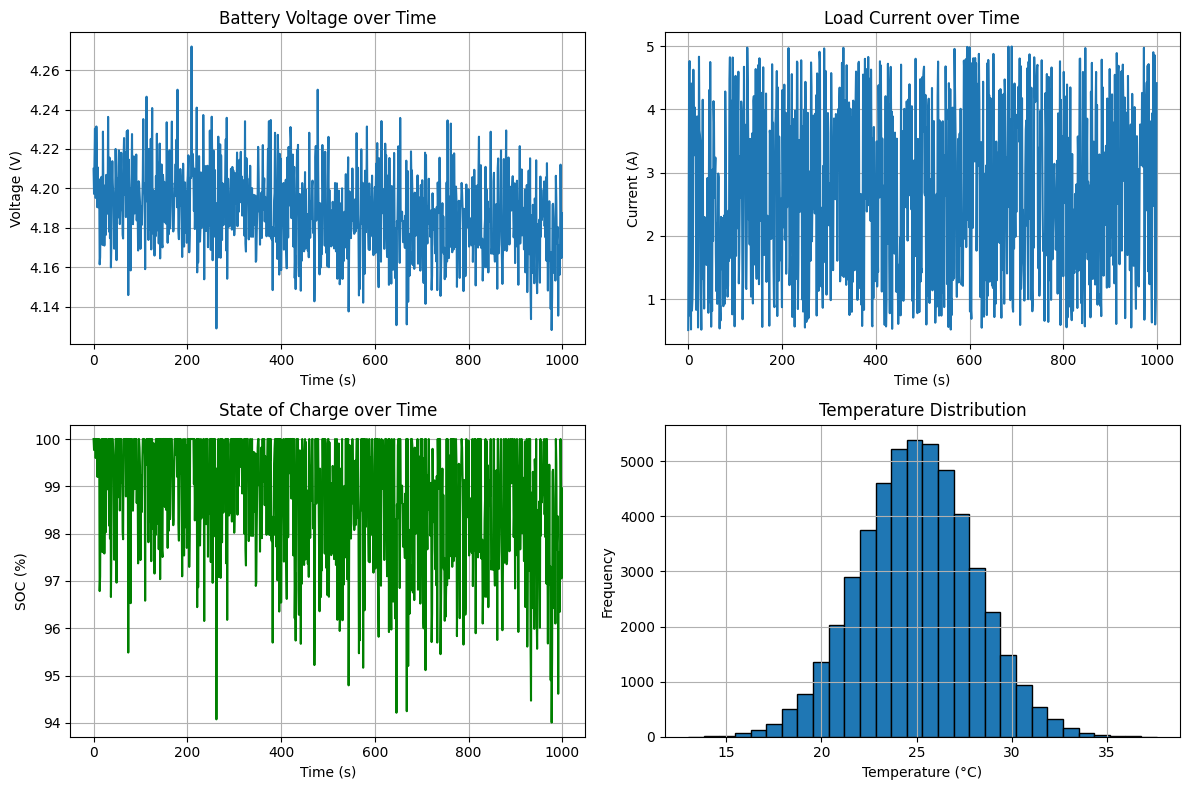

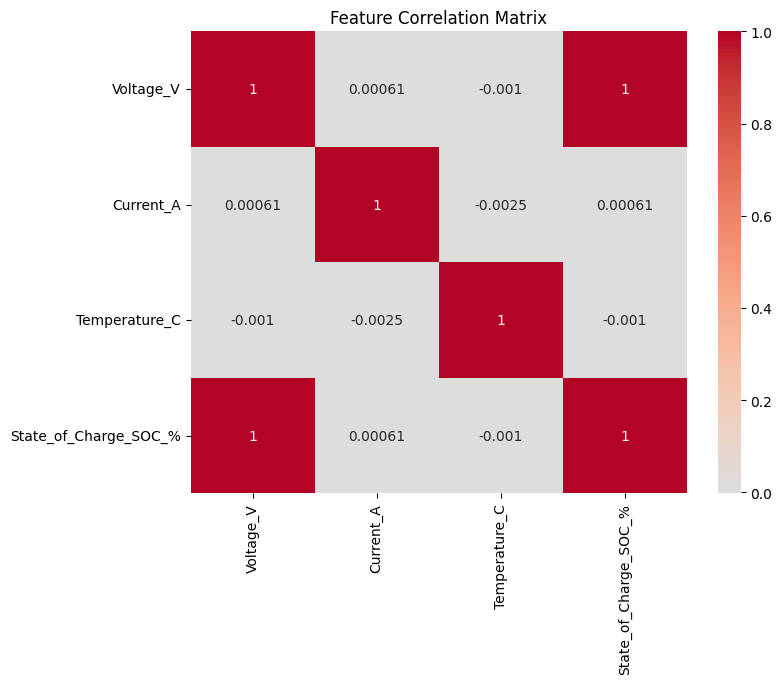

In [ ]:
# Cell 3: Visualize the data
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Voltage vs Time
axes[0, 0].plot(df['Time_s'].values[:1000], df['Voltage_V'].values[:1000])
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Voltage (V)')
axes[0, 0].set_title('Battery Voltage over Time')
axes[0, 0].grid(True)

# Current vs Time
axes[0, 1].plot(df['Time_s'].values[:1000], df['Current_A'].values[:1000])
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Current (A)')
axes[0, 1].set_title('Load Current over Time')
axes[0, 1].grid(True)

# SOC vs Time
axes[1, 0].plot(df['Time_s'].values[:1000], df['State_of_Charge_SOC_%'].values[:1000], 'g-')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('SOC (%)')
axes[1, 0].set_title('State of Charge over Time')
axes[1, 0].grid(True)

# Temperature distribution
axes[1, 1].hist(df['Temperature_C'], bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Temperature Distribution')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Voltage_V', 'Current_A', 'Temperature_C', 'State_of_Charge_SOC_%']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# Cell 4: Prepare data for LSTM
def create_sequences(data, targets, sequence_length=20):
    """
    Create sequences for time series prediction.
    Reference: LSTM model used sequence length of 20 for 1Hz data [citation:4]
    """
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(targets[i + sequence_length])
    return np.array(X), np.array(y)

# Select features for training
feature_columns = ['Voltage_V', 'Current_A', 'Temperature_C']
target_column = 'State_of_Charge_SOC_%'

# Normalize the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[feature_columns])
y_scaled = scaler_y.fit_transform(df[[target_column]])

# Create sequences
SEQUENCE_LENGTH = 20  # As used in published LSTM research [citation:4][citation:9]
X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQUENCE_LENGTH)

print(f"Sequences shape: {X_seq.shape}")
print(f"Targets shape: {y_seq.shape}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Sequences shape: (49980, 20, 3)
Targets shape: (49980, 1)
Training set: (39984, 20, 3)
Test set: (9996, 20, 3)


In [ ]:
# Cell 5: Build LSTM model for SoC estimation
def build_lstm_model(input_shape, units=64, dropout_rate=0.2):
    """
    Build LSTM model architecture based on published research [citation:4][citation:7]
    """
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Build the model
input_shape = (SEQUENCE_LENGTH, len(feature_columns))
model = build_lstm_model(input_shape)

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,425 (122.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 6: Train with callbacks for best performance
# Early stopping prevents overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when plateauing
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - loss: 0.0095 - mae: 0.0565 - val_loss: 0.0013 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.0011 - mae: 0.0253 - val_loss: 0.0020 - val_mae: 0.0389 - learning_rate: 0.0010
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 7.6468e-04 - mae: 0.0214 - val_loss: 3.6038e-04 - val_mae: 0.0151 - learning_rate: 0.0010
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 5.9102e-04 - mae: 0.0190 - val_loss: 0.0011 - val_mae: 0.0276 - learning_rate: 0.0010
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 4.9603e-04 - mae: 0.0175 - val_loss: 0.0023 - val_mae: 0.0408 - learning_rate: 0.0010
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 4.7345e-04 - mae: 0.0172 - val_loss: 0.0021 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 4.4513e-04 - mae: 0.0167 - val_loss: 0.0036 - v

In [ ]:
# Cell 7: Evaluate on test data
# Make predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Calculate metrics - the same ones used in published papers [citation:3][citation:7]
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Mean Absolute Error (MAE):  {mae:.4f} %")
print(f"Mean Squared Error (MSE):   {mse:.6f}")
print(f"Root Mean Squared Error:    {rmse:.4f} %")
print(f"R-squared (R²):             {r2:.4f}")
print("=" * 50)

# Compare with published benchmarks
print("\nComparison with published results:")
print("-" * 40)
print("Published LSTM benchmarks [citation:4][citation:7]:")
print("  • MAE: 0.2255% (LG HG2 dataset)")
print("  • MSE: 0.001374%")
print(f"\nYour model achieved:")
print(f"  • MAE: {mae:.4f}%")
print(f"  • MSE: {mse:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE):  6.3597 %
Mean Squared Error (MSE):   52.669311
Root Mean Squared Error:    7.2574 %
R-squared (R²):             -0.4820

Comparison with published results:
----------------------------------------
Published LSTM benchmarks [citation:4][citation:7]:
  • MAE: 0.2255% (LG HG2 dataset)
  • MSE: 0.001374%

Your model achieved:
  • MAE: 6.3597%
  • MSE: 52.669311


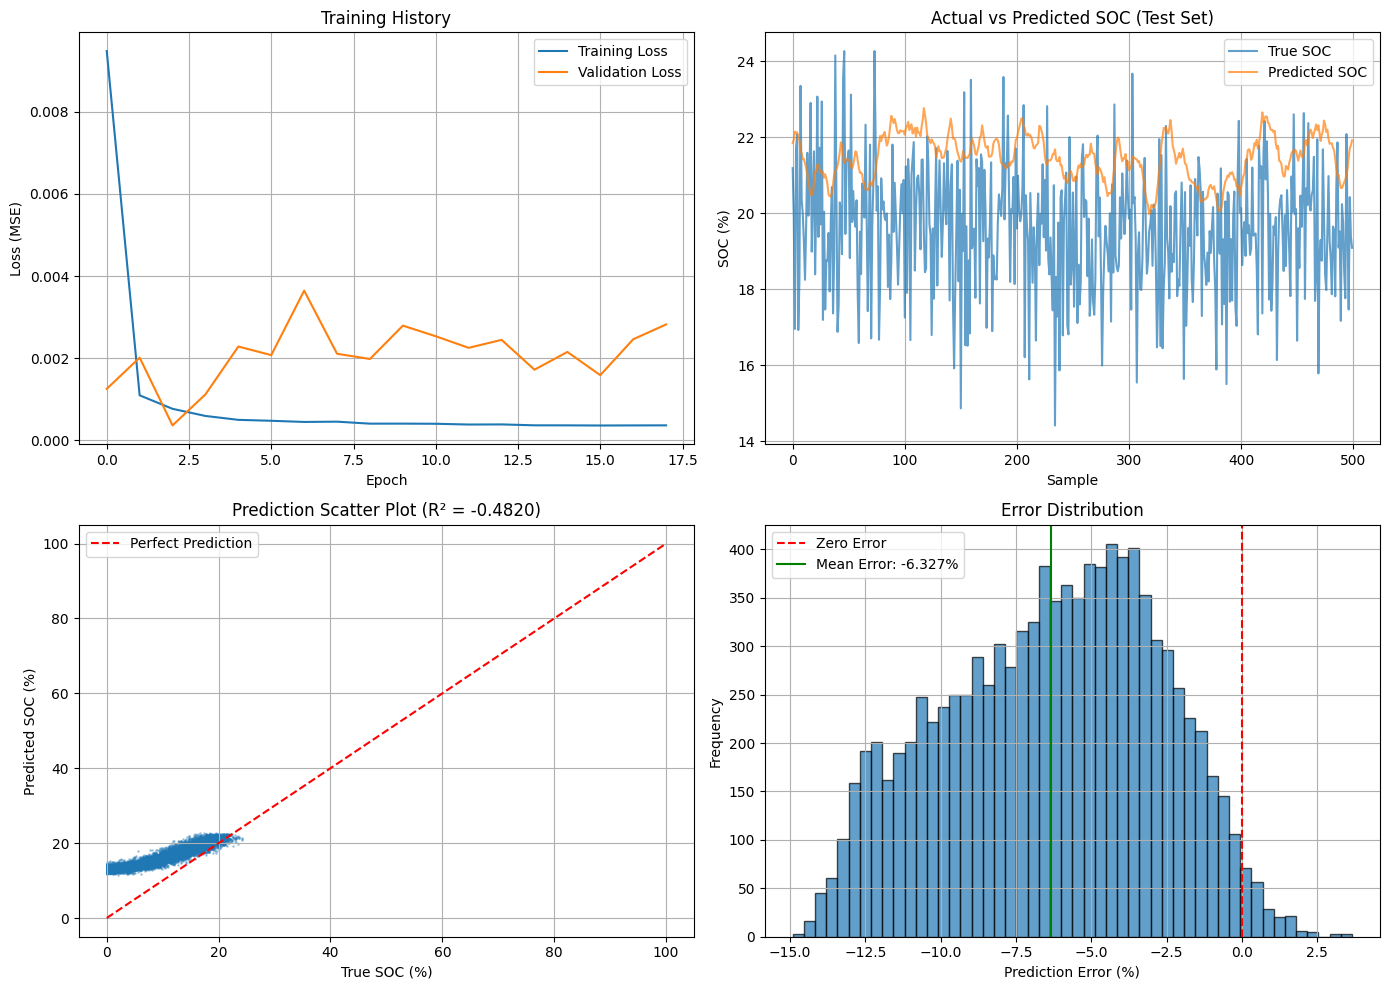

In [ ]:
# Cell 8: Create publication-quality plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training history
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].set_title('Training History')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Actual vs Predicted (first 500 samples)
axes[0, 1].plot(y_true[:500], label='True SOC', alpha=0.7)
axes[0, 1].plot(y_pred[:500], label='Predicted SOC', alpha=0.7)
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('SOC (%)')
axes[0, 1].set_title('Actual vs Predicted SOC (Test Set)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Scatter plot with perfect prediction line
axes[1, 0].scatter(y_true, y_pred, alpha=0.3, s=1)
axes[1, 0].plot([0, 100], [0, 100], 'r--', label='Perfect Prediction')
axes[1, 0].set_xlabel('True SOC (%)')
axes[1, 0].set_ylabel('Predicted SOC (%)')
axes[1, 0].set_title(f'Prediction Scatter Plot (R² = {r2:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Error distribution
errors = (y_true - y_pred).flatten()
axes[1, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', label='Zero Error')
axes[1, 1].axvline(x=np.mean(errors), color='g', linestyle='-', label=f'Mean Error: {np.mean(errors):.3f}%')
axes[1, 1].set_xlabel('Prediction Error (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Error Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('soc_estimation_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 9: Compare different model architectures for your paper
def build_gru_model(input_shape):
    """GRU model as alternative to LSTM [citation:8]"""
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

def build_bilstm_model(input_shape):
    """Bidirectional LSTM for capturing forward/backward dependencies [citation:1]"""
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

# Train and evaluate all models
models = {
    'LSTM': build_lstm_model(input_shape),
    'GRU': build_gru_model(input_shape),
    'BiLSTM': build_bilstm_model(input_shape)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results[name] = {'MAE (%)': mae, 'RMSE (%)': rmse}

    print(f"{name} - MAE: {mae:.4f}%, RMSE: {rmse:.4f}%")

# Display comparison table
print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
comparison_df = pd.DataFrame(results).T
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM...
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
LSTM - MAE: 12.1549%, RMSE: 12.7692%

Training GRU...
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
GRU - MAE: 3.7630%, RMSE: 4.6708%

Training BiLSTM...
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 1.
BiLSTM - MAE: 3.1819%, RMSE: 3.6492%

MODEL COMPARISON SUMMARY
          MAE (%)   RMSE (%)
LSTM    12.154918  12.769176
GRU      3.763018   4.670844
BiLSTM   3.181924   3.649245
